# CIC3 Strategy × Topology Comparison

Compares CIC3 seeding strategies (random, high-degree, high-2-simplex)
across four topologies (RSC, BA, SBM, SBM-Manual) mirroring
`seeding_strategies.ipynb`.

For each (topology, strategy) we run `NUM_TRIALS` independent simulations
and aggregate the results. Headline output: bar charts of mean `A_g` and
`A_g^td` with error bars (trial std), plus per-topology boxplots of
per-contagion attainment to show how evenly each strategy fills quotas
across contagions.

Quotas are chosen so `sum(Q_i) == N` (no slack) so strategy differences
actually surface in the metric.

In [21]:
import sys
sys.path.insert(0, '..')

In [22]:
import numpy as np
import matplotlib.pyplot as plt

from scm import RSCGenerator, BAGenerator, SBMGenerator, CIC3Simulator
from scm import (
    MultiRandomSeeding, MultiHighDegreeSeeding, MultiHighSimplexSeeding,
)
from scm.analysis import (
    attainment, time_discounted_attainment, exponential_decay,
)

STRATEGIES = [
    ("Random", MultiRandomSeeding),
    ("High Degree", MultiHighDegreeSeeding),
    ("High 2-Simplex", MultiHighSimplexSeeding),
]

## Shared parameters

In [23]:
# --- Topology / network parameters ---
N = 500
K_AVG_TARGET = 20
K_D_AVG_TARGET = 6
TOPO_SEED = 2025

# --- Contagion parameters ---
C = 50                            # number of contagions
BETA = 0.04
BETA_DELTA = 0.03
BETAS = [BETA] * C
BETA_DELTAS = [BETA_DELTA] * C
QUOTAS = [N // C] * C             # sums to N (assuming C divides N)
assert sum(QUOTAS) == N, (
    f"sum(QUOTAS)={sum(QUOTAS)} but N={N}; pick C that divides N or "
    "adjust QUOTAS manually"
)

# Per-contagion seeds: a small fraction of each quota pre-infected.
SEEDS_PER_CONTAGION = [max(1, q // 5) for q in QUOTAS]

# --- Simulation parameters ---
T_MAX = 200
V_RATE = 0.05
V = exponential_decay(V_RATE)
NUM_TRIALS = 5

## Topology configurations

Mirrors `seeding_strategies.ipynb` but single-N. RSC / BA / SBM /
SBM-Manual factories are invoked once each; the realized adjacency
lists are reused across strategies and trials.

In [24]:
# --- BA defaults ---
BA_M = 5
BA_M_DELTA = 2

# --- SBM defaults (auto-computed, 4 equal communities) ---
SBM_K = 4
SBM_INTRA_FRAC = 0.8
SBM_KAVG_EDGE = 14


def make_sbm_block_matrix(N=None, K=SBM_K, intra_frac=SBM_INTRA_FRAC,
                          k_avg_edge=SBM_KAVG_EDGE, values=None):
    if values is not None:
        return np.asarray(values, dtype=float)
    p_intra = intra_frac * k_avg_edge * K / N
    p_inter = (1 - intra_frac) * k_avg_edge * K / (N * (K - 1))
    bm = np.full((K, K), p_inter)
    np.fill_diagonal(bm, p_intra)
    return bm


def make_sbm_triangle_kwarg(N=None, K=SBM_K, k_delta_avg=K_D_AVG_TARGET,
                             values=None):
    if values is None:
        p_tri = k_delta_avg * 2 * K ** 2 / N ** 2
        return {"triangle_block_probs": [p_tri] * K}
    arr = np.asarray(values, dtype=float)
    if arr.ndim == 1:
        return {"triangle_block_probs": arr.tolist()}
    if arr.ndim == 3:
        return {"triangle_block_tensor": arr}
    raise ValueError("triangle values must be 1D or 3D")


def equal_community_sizes(N, K=SBM_K):
    base = N // K
    sizes = [base] * K
    sizes[-1] += N - base * K
    return sizes


# --- Manual SBM instance, scaled for this N ---
# Original seeding_strategies values were tuned for N=2000. Here we scale
# community sizes linearly and rescale probabilities by (2000/N) (edges)
# and (2000/N)^2 (triangles) so realized k_avg / k_delta_avg stay
# comparable.
SBM_MANUAL_K = 5
_BASE_N = 2000
_SCALE = _BASE_N / N
SBM_MANUAL_SIZES = [int(round(s / _SCALE)) for s in [800, 600, 400, 180, 20]]
SBM_MANUAL_SIZES[-1] += N - sum(SBM_MANUAL_SIZES)   # absorb rounding drift

_BASE_MANUAL_BLOCK = [
    [0.020, 0.003, 0.001, 0.000, 0.3],
    [0.003, 0.025, 0.004, 0.001, 0.3],
    [0.001, 0.004, 0.035, 0.005, 0.3],
    [0.000, 0.001, 0.005, 0.060, 0.3],
    [0.3,   0.3,   0.3,   0.3,   0.3],
]
SBM_MANUAL_BLOCK = np.clip(
    np.asarray(_BASE_MANUAL_BLOCK) * _SCALE, 0.0, 1.0,
).tolist()

_BASE_MANUAL_TRI = [3e-5, 4e-5, 6e-5, 1e-4, 1e-3]
SBM_MANUAL_TRI = np.clip(
    np.asarray(_BASE_MANUAL_TRI) * _SCALE ** 2, 0.0, 1.0,
).tolist()


TOPOLOGY_CONFIGS = [
    {
        "name": "RSC",
        "make": lambda: RSCGenerator(
            k_avg=K_AVG_TARGET, k_delta_avg=K_D_AVG_TARGET, N=N),
    },
    {
        "name": "BA",
        "make": lambda: BAGenerator(m=BA_M, m_delta=BA_M_DELTA, N=N),
    },
    {
        "name": "SBM",
        "make": lambda: SBMGenerator(
            community_sizes=equal_community_sizes(N),
            block_matrix=make_sbm_block_matrix(N=N),
            **make_sbm_triangle_kwarg(N=N),
        ),
    },
    {
        "name": "SBM-Manual",
        "make": lambda: SBMGenerator(
            community_sizes=SBM_MANUAL_SIZES,
            block_matrix=make_sbm_block_matrix(values=SBM_MANUAL_BLOCK),
            **make_sbm_triangle_kwarg(
                K=SBM_MANUAL_K, values=SBM_MANUAL_TRI),
        ),
    },
]

## Generate topologies

In [25]:
topologies = {}
for config in TOPOLOGY_CONFIGS:
    name = config["name"]
    print(f"\n--- Generating {name} ---")
    gen = config["make"]()
    links, triangles = gen.generate(seed=TOPO_SEED)
    topologies[name] = {
        "links": links, "triangles": triangles,
        "k_avg": gen.k_avg, "k_d_avg": gen.k_delta_avg,
    }


--- Generating RSC ---
Sampling edges with p_1 = 0.01642710
Edges sampled: 1982/1982
Sampling triangles with p_delta = 0.00004829
Triangles sampled: 1057/1057
Realized k_avg = 20.29, k_delta_avg = 6.34

--- Generating BA ---
BA nodes added: 500/500
Realized k_avg = 20.54, k_delta_avg = 6.15

--- Generating SBM ---
Sampling edges per block-pair
SBM edges sampled (through block 3,3): 3427
Sampling triangles per block-triple
SBM triangles sampled (through block 3,3,3): 984
Realized k_avg = 24.03, k_delta_avg = 5.90

--- Generating SBM-Manual ---
Sampling edges per block-pair
SBM edges sampled (through block 4,4): 6820
Sampling triangles per block-triple
SBM triangles sampled (through block 4,4,4): 1153
Realized k_avg = 39.18, k_delta_avg = 6.92


## Run trials

For each (topology, strategy) pair, run `NUM_TRIALS` independent
simulations. Each trial records `A_g`, `A_g^td`, and the per-contagion
`A_i`, `A_i^td` arrays. Trial-to-trial variance comes from:

- For `Random`: random seed selection + stochastic simulation.
- For `High Degree` / `High 2-Simplex`: stochastic simulation only
  (seed selection is deterministic given the topology), with a tiny
  amount of reshuffling from round-robin tie-breaks when multiple
  nodes share the same degree rank.

In [26]:
def run_trial(links, triangles, strat_cls):
    seeder = strat_cls(
        N=N, num_seeds_per_contagion=SEEDS_PER_CONTAGION,
        links=links, triangles=triangles,
    )
    seeds = seeder.seed()
    sim = CIC3Simulator(
        links=links, triangles=triangles,
        initial_infected_per_contagion=seeds,
        betas=BETAS, beta_deltas=BETA_DELTAS, quotas=QUOTAS,
    )
    sim.run(T_MAX)
    A_i, A_g = attainment(sim.infected_by, QUOTAS)
    A_i_td, A_g_td = time_discounted_attainment(
        sim.infected_by, sim.infection_times, QUOTAS, V,
    )
    return {"A_g": A_g, "A_g_td": A_g_td, "A_i": A_i, "A_i_td": A_i_td}


all_results = {}
for config in TOPOLOGY_CONFIGS:
    name = config["name"]
    topo = topologies[name]
    print(f"\n=== Topology: {name} ===")
    topo_results = {}
    for strat_name, strat_cls in STRATEGIES:
        trials = []
        for t in range(NUM_TRIALS):
            print(f"  [{strat_name}] trial {t + 1}/{NUM_TRIALS}")
            trials.append(run_trial(
                topo["links"], topo["triangles"], strat_cls,
            ))
        topo_results[strat_name] = trials
    all_results[name] = topo_results


=== Topology: RSC ===
  [Random] trial 1/5
  [Random] trial 2/5
  [Random] trial 3/5
  [Random] trial 4/5
  [Random] trial 5/5
  [High Degree] trial 1/5
  [High Degree] trial 2/5
  [High Degree] trial 3/5
  [High Degree] trial 4/5
  [High Degree] trial 5/5
  [High 2-Simplex] trial 1/5
  [High 2-Simplex] trial 2/5
  [High 2-Simplex] trial 3/5
  [High 2-Simplex] trial 4/5
  [High 2-Simplex] trial 5/5

=== Topology: BA ===
  [Random] trial 1/5
  [Random] trial 2/5
  [Random] trial 3/5
  [Random] trial 4/5
  [Random] trial 5/5
  [High Degree] trial 1/5
  [High Degree] trial 2/5
  [High Degree] trial 3/5
  [High Degree] trial 4/5
  [High Degree] trial 5/5
  [High 2-Simplex] trial 1/5
  [High 2-Simplex] trial 2/5
  [High 2-Simplex] trial 3/5
  [High 2-Simplex] trial 4/5
  [High 2-Simplex] trial 5/5

=== Topology: SBM ===
  [Random] trial 1/5
  [Random] trial 2/5
  [Random] trial 3/5
  [Random] trial 4/5
  [Random] trial 5/5
  [High Degree] trial 1/5
  [High Degree] trial 2/5
  [High Degree]

## Aggregate

Mean and std of `A_g` / `A_g^td` across trials, and a pooled
per-contagion `A_i^td` array per (topology, strategy).

In [27]:
summary = {}
for name, topo_results in all_results.items():
    summary[name] = {}
    for strat_name, trials in topo_results.items():
        A_g_arr = np.array([tr["A_g"] for tr in trials])
        A_g_td_arr = np.array([tr["A_g_td"] for tr in trials])
        A_i_td_pooled = np.concatenate([tr["A_i_td"] for tr in trials])
        summary[name][strat_name] = {
            "A_g_mean": A_g_arr.mean(), "A_g_std": A_g_arr.std(ddof=1) if len(A_g_arr) > 1 else 0.0,
            "A_g_td_mean": A_g_td_arr.mean(), "A_g_td_std": A_g_td_arr.std(ddof=1) if len(A_g_td_arr) > 1 else 0.0,
            "A_i_td_pooled": A_i_td_pooled,
        }

# Tabular print
header = f"{'Topology':<12s}{'Strategy':<18s}{'A_g (mean\u00b1std)':<22s}{'A_g_td (mean\u00b1std)':<22s}"
print(header)
print("-" * len(header))
for name in summary:
    for strat_name, s in summary[name].items():
        print(
            f"{name:<12s}{strat_name:<18s}"
            f"{s['A_g_mean']:.3f}\u00b1{s['A_g_std']:.3f}      "
            f"{s['A_g_td_mean']:.3f}\u00b1{s['A_g_td_std']:.3f}"
        )

Topology    Strategy          A_g (mean±std)        A_g_td (mean±std)     
--------------------------------------------------------------------------
RSC         Random            0.774±0.020      0.698±0.014
RSC         High Degree       0.818±0.009      0.737±0.004
RSC         High 2-Simplex    0.812±0.012      0.734±0.012
BA          Random            0.666±0.028      0.604±0.026
BA          High Degree       0.830±0.016      0.748±0.015
BA          High 2-Simplex    0.817±0.025      0.736±0.020
SBM         Random            0.795±0.003      0.724±0.004
SBM         High Degree       0.815±0.008      0.743±0.005
SBM         High 2-Simplex    0.820±0.018      0.746±0.016
SBM-Manual  Random            0.725±0.021      0.675±0.017
SBM-Manual  High Degree       0.624±0.009      0.589±0.008
SBM-Manual  High 2-Simplex    0.672±0.009      0.628±0.009


## Plot: headline attainment per strategy across topologies

Grouped bar chart. x = topology, hue = strategy, bars = mean `A_g^td`
with error bars = trial std. Raw `A_g` shown as a faint secondary bar
so you can see how much the time discount costs each strategy.

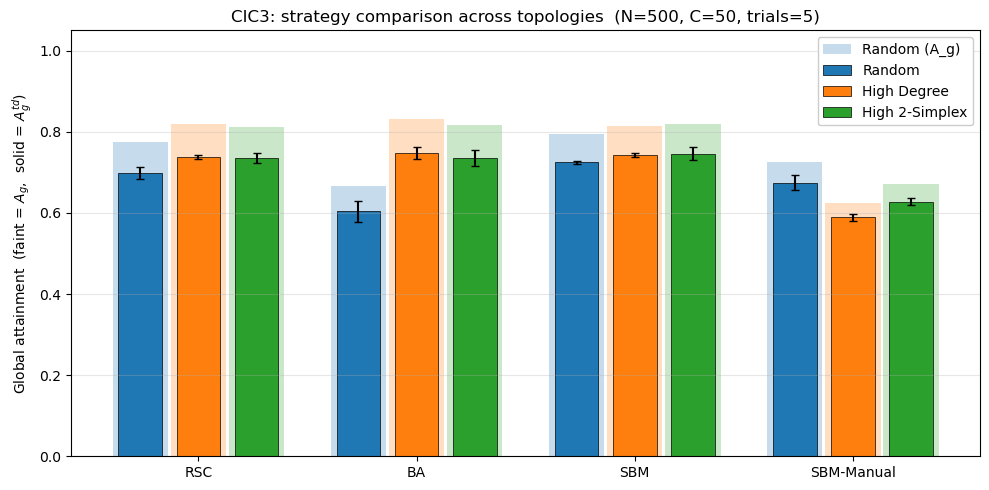

In [28]:
topo_names = [config["name"] for config in TOPOLOGY_CONFIGS]
strat_names = [s[0] for s in STRATEGIES]
strat_colors = plt.cm.tab10(np.linspace(0, 1, 10))[: len(strat_names)]

x = np.arange(len(topo_names))
group_width = 0.8
bar_width = group_width / len(strat_names)

fig, ax = plt.subplots(figsize=(10, 5))

for si, strat_name in enumerate(strat_names):
    means_td = [summary[t][strat_name]["A_g_td_mean"] for t in topo_names]
    stds_td = [summary[t][strat_name]["A_g_td_std"] for t in topo_names]
    means_raw = [summary[t][strat_name]["A_g_mean"] for t in topo_names]

    offset = (si - (len(strat_names) - 1) / 2) * bar_width
    # Faint raw A_g bar behind
    ax.bar(
        x + offset, means_raw, width=bar_width * 0.95,
        color=strat_colors[si], alpha=0.25,
        edgecolor="none",
        label=f"{strat_name} (A_g)" if si == 0 else None,
    )
    # A_g^td bar with error bars in front
    ax.bar(
        x + offset, means_td, width=bar_width * 0.75,
        color=strat_colors[si], edgecolor="black", linewidth=0.5,
        yerr=stds_td, capsize=3,
        label=strat_name,
    )

ax.set_xticks(x)
ax.set_xticklabels(topo_names)
ax.set_ylabel(r"Global attainment  (faint = $A_g$,  solid = $A_g^{td}$)")
ax.set_ylim(0, 1.05)
ax.set_title(
    f"CIC3: strategy comparison across topologies  "
    f"(N={N}, C={C}, trials={NUM_TRIALS})"
)
ax.legend(loc="upper right", framealpha=1)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig("../figures/cic3_strategy_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

## Plot: distribution of per-contagion attainment

One subplot per topology, boxplot of per-contagion `A_i^td` pooled
across trials. A strategy that hits the same mean `A_g^td` with a
tighter per-contagion distribution is filling quotas more evenly.
A long lower tail means some contagions were badly underserved.

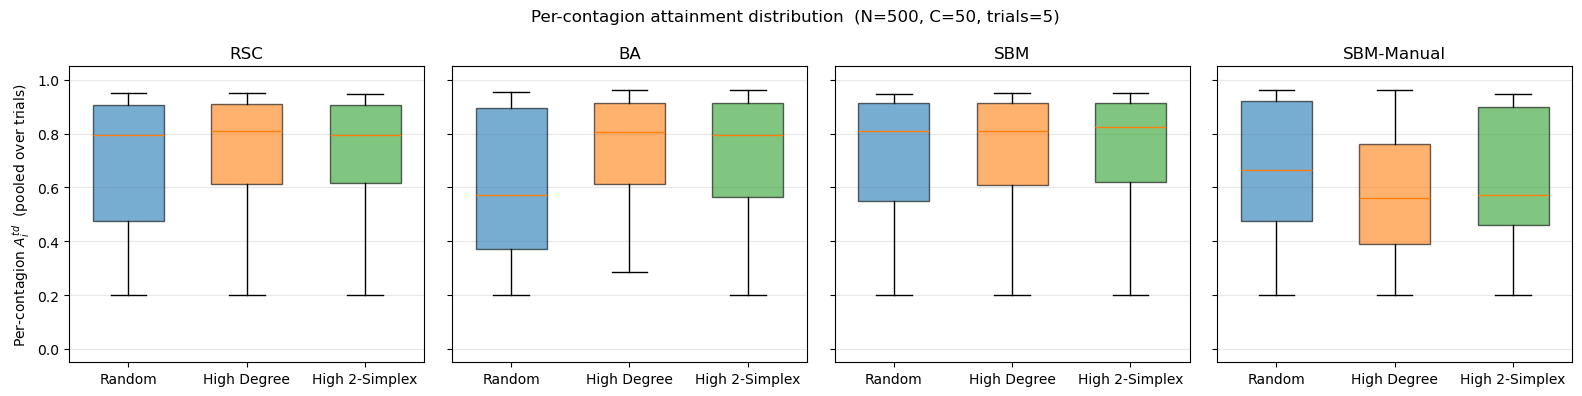

In [29]:
fig, axes = plt.subplots(
    1, len(topo_names), figsize=(4 * len(topo_names), 4), sharey=True,
)
if len(topo_names) == 1:
    axes = [axes]

for ax, name in zip(axes, topo_names):
    data = [summary[name][s]["A_i_td_pooled"] for s in strat_names]
    bp = ax.boxplot(
        data, tick_labels=strat_names, patch_artist=True, widths=0.6,
    )
    for patch, color in zip(bp["boxes"], strat_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(name)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel(r"Per-contagion $A_i^{td}$  (pooled over trials)")
fig.suptitle(
    f"Per-contagion attainment distribution  (N={N}, C={C}, trials={NUM_TRIALS})",
    fontsize=12,
)
fig.tight_layout()
fig.savefig("../figures/cic3_per_contagion_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

## Plot: overlapping per-contagion attainment PDFs

Same data as the boxplot above, rendered as overlapping density curves
so you can see shape differences that a 5-number boxplot hides — e.g.
bimodality (some contagions fully filled, others zero), heavy left
tails (a handful of badly-underserved contagions), or a narrow spike
at 1.0 (all contagions saturated).

Dependency-free — uses `np.histogram(density=True)` rather than a KDE.

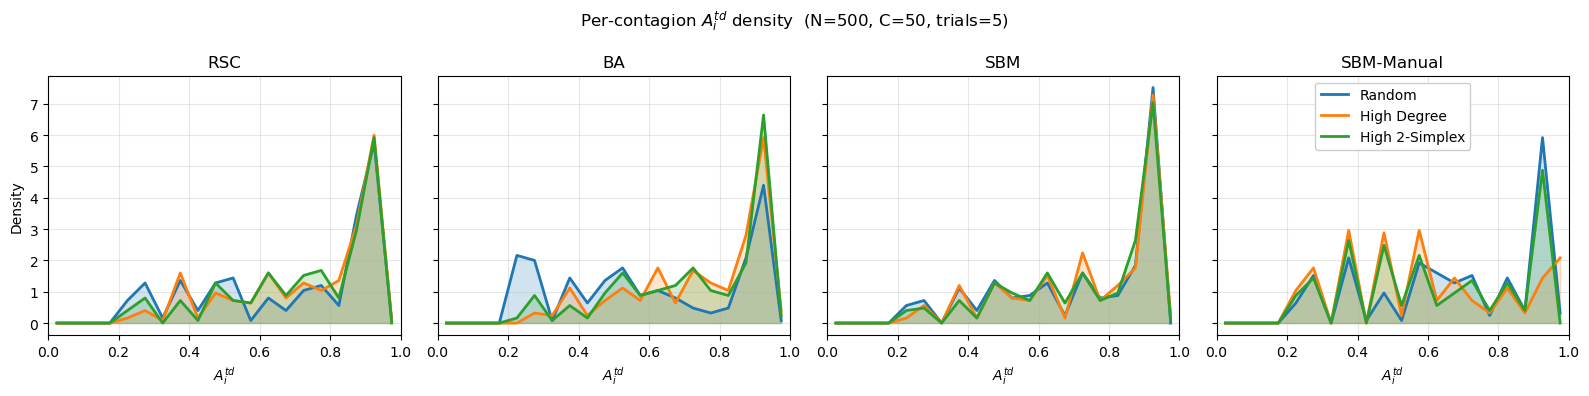

In [30]:
PDF_BINS = 20

fig, axes = plt.subplots(
    1, len(topo_names), figsize=(4 * len(topo_names), 4), sharey=True,
)
if len(topo_names) == 1:
    axes = [axes]

for ax, name in zip(axes, topo_names):
    for si, strat_name in enumerate(strat_names):
        data = summary[name][strat_name]["A_i_td_pooled"]
        counts, edges = np.histogram(
            data, bins=PDF_BINS, range=(0.0, 1.0), density=True,
        )
        centers = 0.5 * (edges[:-1] + edges[1:])
        ax.plot(centers, counts, color=strat_colors[si], lw=2, label=strat_name)
        ax.fill_between(centers, 0, counts, color=strat_colors[si], alpha=0.2)

    ax.set_title(name)
    ax.set_xlim(0, 1)
    ax.set_xlabel(r"$A_i^{td}$")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Density")
axes[-1].legend(loc="upper center", framealpha=1)
fig.suptitle(
    f"Per-contagion $A_i^{{td}}$ density  (N={N}, C={C}, trials={NUM_TRIALS})",
    fontsize=12,
)
fig.tight_layout()
fig.savefig("../figures/cic3_per_contagion_pdf.png", dpi=200, bbox_inches="tight")
plt.show()